# 02. Exploració inicial del dataset

Aquest notebook fa una exploració descriptiva del dataset final:

1. Control de qualitat.
2. Mapa esquemàtic de les subregions.
3. Distribucions de les variables principals.
4. Evolució temporal dels índexs de teleconnexió.
5. Comparació bàsica entre subregions.
6. Exportació de figures a la carpeta `figures/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BASE = Path("..") if Path("../data_processed").exists() else Path(".")
PROC = BASE / "data_processed"
FIG = BASE / "figures"
FIG.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROC / "teleconnections_catalonia_1981_2020_main_v2.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["data"])

print(df.shape)
df.head()

(1920, 38)


,data,any,mes,dies_mes,estacio,periode,subregio,nao,wemo,roni,...,anomalia_sst,mes_molt_calid,mes_molt_fred,mes_molt_sec,mes_molt_humit,sol_molt_sec,sol_molt_humit,episodi_calid_i_sec,episodi_fred_i_humit,episodi_calid_i_sol_sec
0,1981-01-01,1981,1,31,Winter,1981-1990,Llevant_Iberic,1.00,1.27,0.0,...,-0.891328,False,True,False,False,True,False,False,False,False
1,1981-02-01,1981,2,28,Winter,1981-1990,Llevant_Iberic,1.04,-0.18,-0.3,...,-0.814626,False,True,False,False,True,False,False,False,False
2,1981-03-01,1981,3,31,Spring,1981-1990,Llevant_Iberic,0.01,0.48,-0.3,...,-0.302593,True,False,False,False,True,False,False,False,True
3,1981-04-01,1981,4,30,Spring,1981-1990,Llevant_Iberic,-3.04,-1.36,-0.3,...,-0.168856,False,False,False,True,False,True,False,False,False
4,1981-05-01,1981,5,31,Spring,1981-1990,Llevant_Iberic,0.05,1.69,-0.3,...,-1.155891,False,True,False,False,False,True,False,False,False


In [2]:
print("Rang temporal:", df["data"].min(), "->", df["data"].max())
print("Duplicats data-subregio:", df.duplicated(subset=["data", "subregio"]).sum())

print("\nPercentatge de valors nuls:")
display((df.isna().mean() * 100).sort_values(ascending=False).head(15))

print("\nObservacions per subregió:")
display(df["subregio"].value_counts())

print("\nObservacions per estació:")
display(df["estacio"].value_counts())

print("\nObservacions per període:")
display(df["periode"].value_counts())

Rang temporal: 1981-01-01 00:00:00 -> 2020-12-01 00:00:00
Duplicats data-subregio: 0

Percentatge de valors nuls:


data                   0.0
any                    0.0
mes                    0.0
dies_mes               0.0
estacio                0.0
periode                0.0
subregio               0.0
nao                    0.0
wemo                   0.0
roni                   0.0
fase_nao               0.0
fase_wemo              0.0
fase_enso              0.0
temperatura_mitjana    0.0
precipitacio_mm_dia    0.0
dtype: float64


Observacions per subregió:


subregio
Llevant_Iberic                    480
Catalunya_Balears                 480
Golf_Lleo                         480
Mediterrani_Central_Occidental    480
Name: count, dtype: int64


Observacions per estació:


estacio
Winter    480
Spring    480
Summer    480
Autumn    480
Name: count, dtype: int64


Observacions per període:


periode
1981-1990    480
1991-2000    480
2001-2010    480
2011-2020    480
Name: count, dtype: int64

In [3]:
regions_df = pd.read_csv(PROC / "definicio_subregions_v2.csv")

regions = (
    regions_df
    .set_index("subregio")[["lat_min", "lat_max", "lon_min", "lon_max"]]
    .to_dict(orient="index")
)

regions_df

,subregio,lat_min,lat_max,lon_min,lon_max,descripcio
0,Llevant_Iberic,36.0,40.5,-2.0,0.5,"Costa mediterrània del País Valencià, Múrcia i..."
1,Catalunya_Balears,39.0,42.8,0.5,5.0,"Catalunya, Illes Balears i mar Balear proper."
2,Golf_Lleo,42.8,45.0,2.0,7.0,Golf del Lleó i costa mediterrània francesa.
3,Mediterrani_Central_Occidental,37.5,42.8,5.0,9.5,Mar obert del Mediterrani occidental central i...


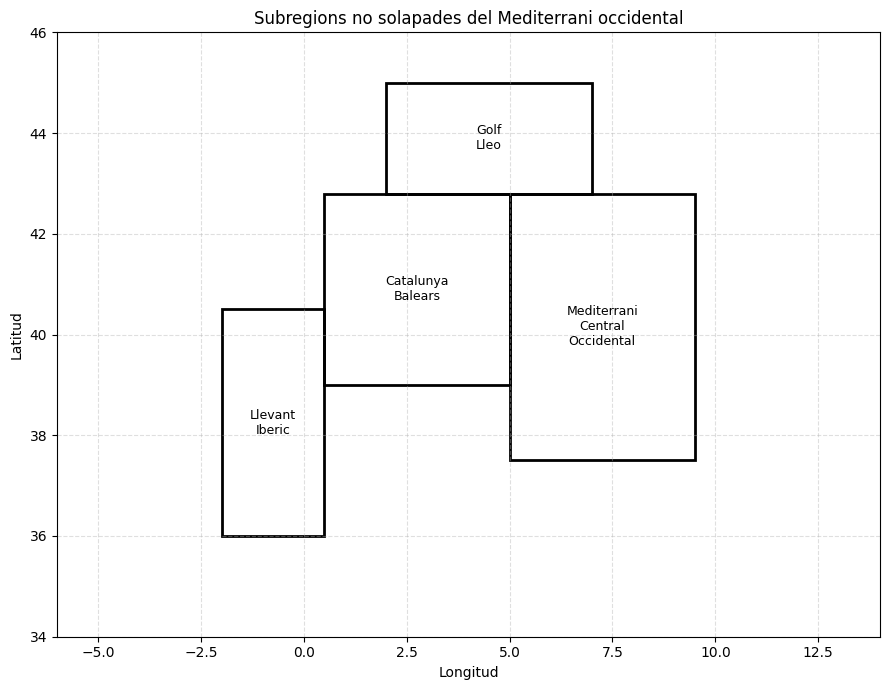

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))

for nom, r in regions.items():
    rect = Rectangle(
        (r["lon_min"], r["lat_min"]),
        r["lon_max"] - r["lon_min"],
        r["lat_max"] - r["lat_min"],
        linewidth=2,
        edgecolor="black",
        facecolor="none"
    )
    ax.add_patch(rect)

    lon_c = (r["lon_min"] + r["lon_max"]) / 2
    lat_c = (r["lat_min"] + r["lat_max"]) / 2

    ax.text(
        lon_c, lat_c, nom.replace("_", "\n"),
        ha="center", va="center", fontsize=9
    )

ax.set_xlim(-6, 14)
ax.set_ylim(34, 46)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Subregions no solapades del Mediterrani occidental")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIG / "02_mapa_subregions.png", dpi=300)
plt.show()

In [5]:
vars_num = [
    "nao", "wemo", "roni",
    "temperatura_mitjana",
    "precipitacio_mm_dia",
    "precipitacio_mensual_mm",
    "humitat_sol_capa1",
    "temperatura_superficie_mar",
    "anomalia_temperatura",
    "anomalia_precipitacio_mensual_mm",
    "anomalia_humitat_sol_capa1",
    "anomalia_sst",
]

desc = df[vars_num].describe().T
display(desc)

desc.to_csv(PROC / "eda_estadistics_basics_v2.csv")

,count,mean,std,min,25%,50%,75%,max
nao,1920.0,3.577083e-02,1.834860,-4.700000,-1.232500,0.015000,1.345000,5.260000
wemo,1920.0,-8.660417e-02,1.085887,-3.180000,-0.810000,-0.115000,0.680000,3.190000
roni,1920.0,2.270833e-02,0.909612,-1.900000,-0.600000,-0.100000,0.525000,2.500000
temperatura_mitjana,1920.0,1.546572e+01,5.657577,-1.293758,11.556601,14.855284,20.336144,27.416777
precipitacio_mm_dia,1920.0,1.677297e+00,1.231651,0.014241,0.737631,1.423006,2.351679,8.113246
precipitacio_mensual_mm,1920.0,5.098098e+01,37.457213,0.441478,22.568470,43.374378,71.541129,251.510625
humitat_sol_capa1,1920.0,2.779741e-01,0.078914,0.109415,0.219815,0.289668,0.347822,0.406230
temperatura_superficie_mar,1920.0,1.829428e+01,4.066862,11.700174,14.657728,17.651597,21.828680,27.904104
anomalia_temperatura,1920.0,-3.776234e-08,1.076135,-5.158640,-0.684804,-0.001745,0.719117,4.052212
anomalia_precipitacio_mensual_mm,1920.0,1.776357e-16,27.838936,-93.401315,-17.065354,-3.261848,14.003614,139.438251


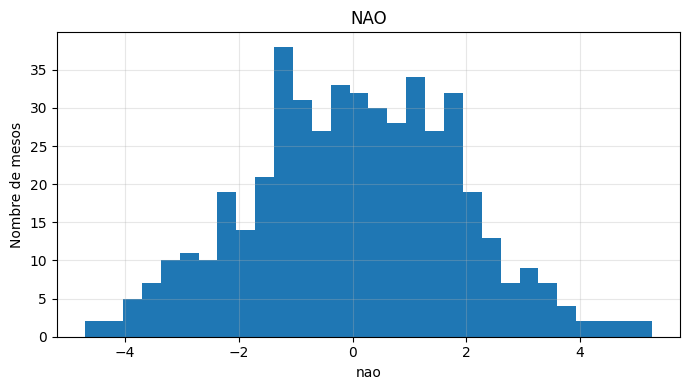

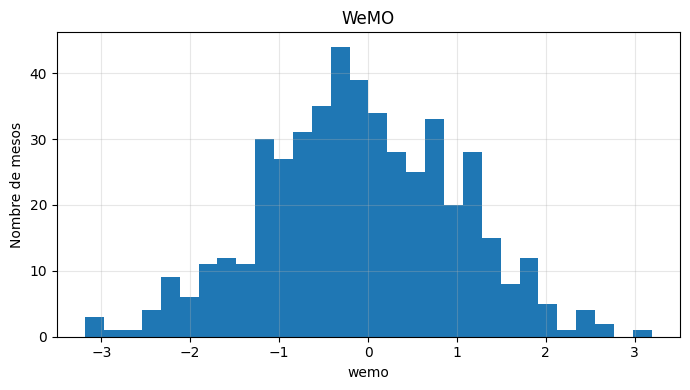

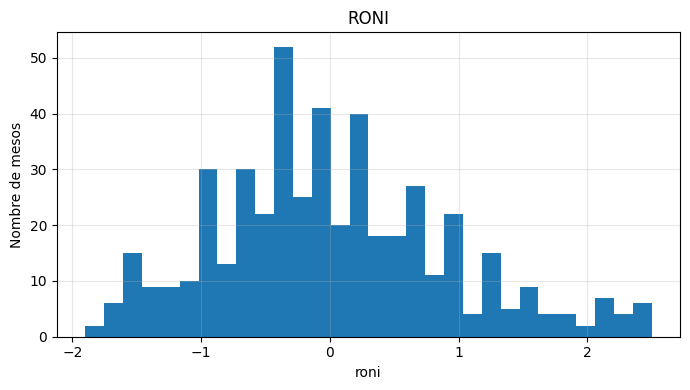

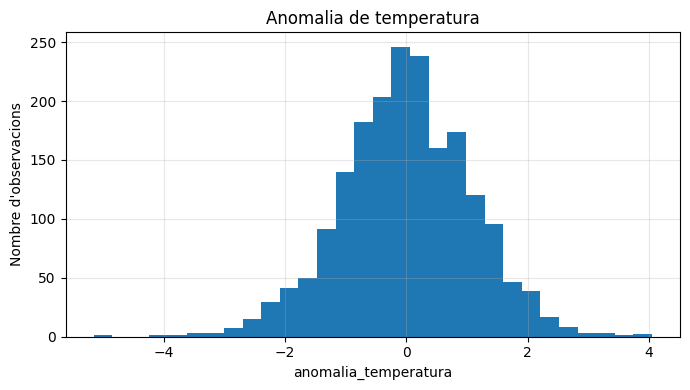

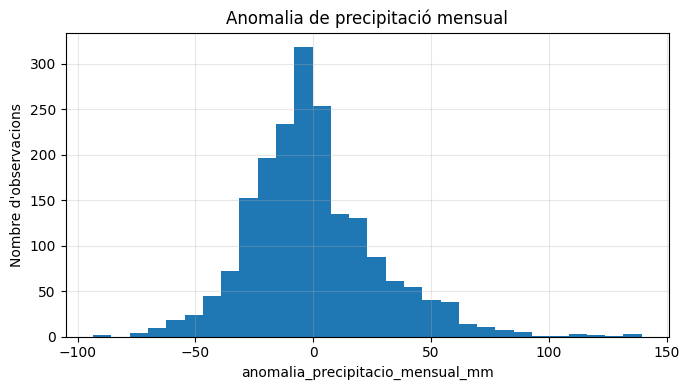

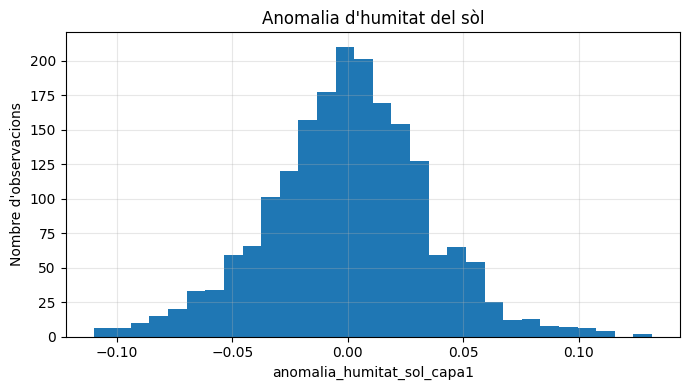

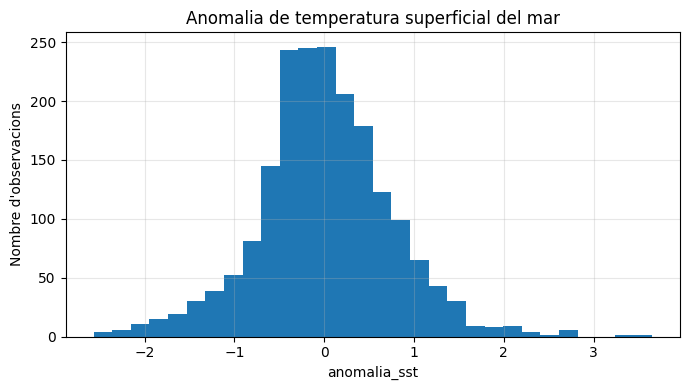

In [6]:
# Distribucions de les teleconnexions: una observació per mes
tele = (
    df[["data", "nao", "wemo", "roni"]]
    .drop_duplicates()
    .sort_values("data")
)

variables_tele = [
    ("nao", "NAO"),
    ("wemo", "WeMO"),
    ("roni", "RONI"),
]

for col, title in variables_tele:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(tele[col].dropna(), bins=30)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre de mesos")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG / f"02_distribucio_{col}.png", dpi=300)
    plt.show()


# Distribucions de les anomalies climàtiques: una observació per mes i subregió
variables_clima = [
    ("anomalia_temperatura", "Anomalia de temperatura"),
    ("anomalia_precipitacio_mensual_mm", "Anomalia de precipitació mensual"),
    ("anomalia_humitat_sol_capa1", "Anomalia d'humitat del sòl"),
    ("anomalia_sst", "Anomalia de temperatura superficial del mar"),
]

for col, title in variables_clima:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre d'observacions")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG / f"02_distribucio_{col}.png", dpi=300)
    plt.show()

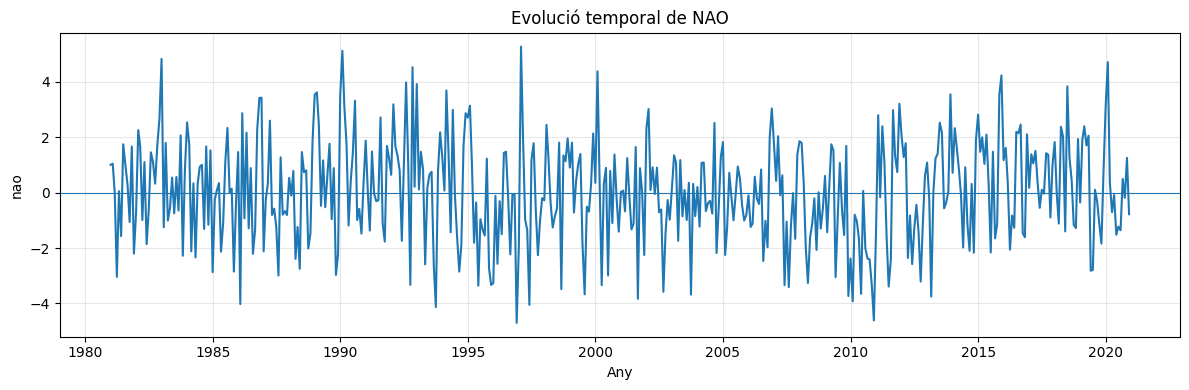

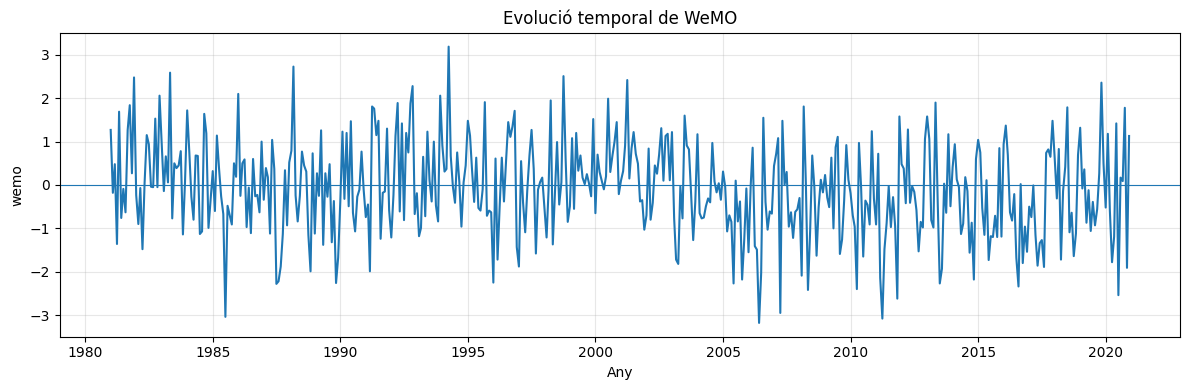

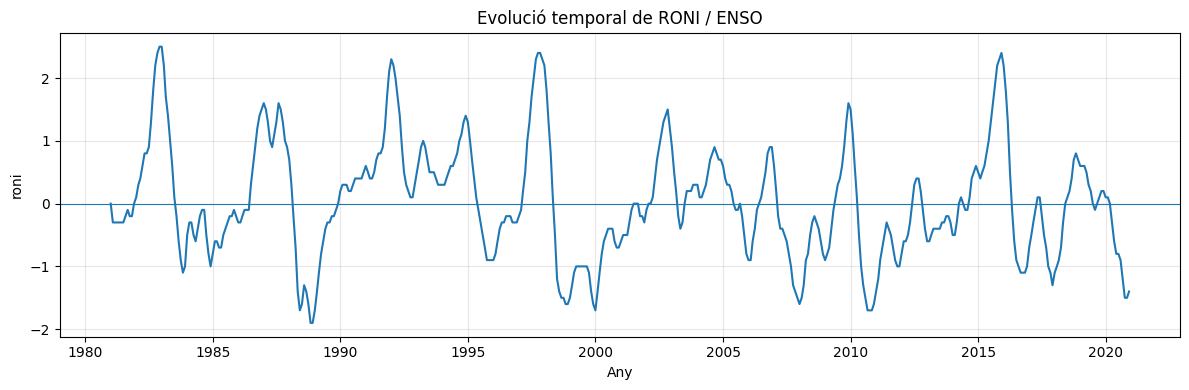

In [7]:
tele = (
    df[["data", "nao", "wemo", "roni"]]
    .drop_duplicates()
    .sort_values("data")
)

for col, title in [("nao", "NAO"), ("wemo", "WeMO"), ("roni", "RONI / ENSO")]:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(tele["data"], tele[col])
    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"Evolució temporal de {title}")
    ax.set_xlabel("Any")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG / f"02_serie_{col}.png", dpi=300)
    plt.show()

In [8]:
resum_subregio = (
    df.groupby("subregio", observed=True)[
        [
            "temperatura_mitjana",
            "precipitacio_mensual_mm",
            "humitat_sol_capa1",
            "temperatura_superficie_mar",
        ]
    ]
    .mean()
    .reset_index()
)

display(resum_subregio)
resum_subregio.to_csv(PROC / "eda_resum_subregions_v2.csv", index=False)

,subregio,temperatura_mitjana,precipitacio_mensual_mm,humitat_sol_capa1,temperatura_superficie_mar
0,Catalunya_Balears,16.175616,47.560034,0.308920,18.554541
1,Golf_Lleo,11.636098,78.934454,0.329919,16.826915
2,Llevant_Iberic,16.750861,33.675698,0.220399,19.183854
3,Mediterrani_Central_Occidental,17.300290,43.753743,0.252659,18.611827


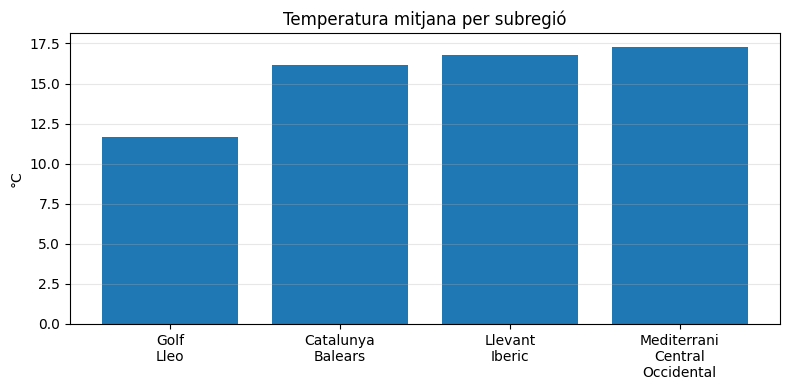

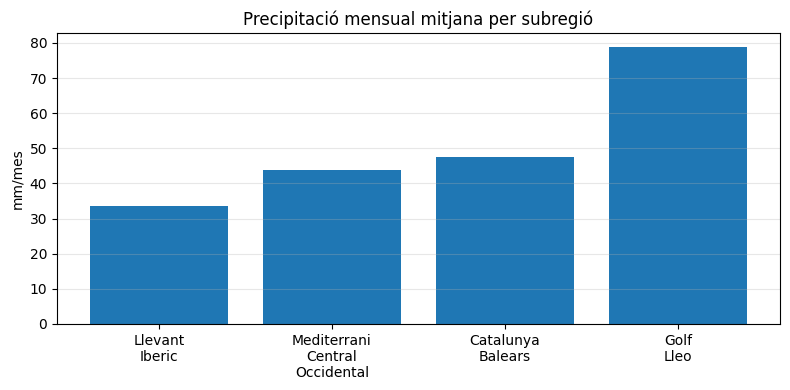

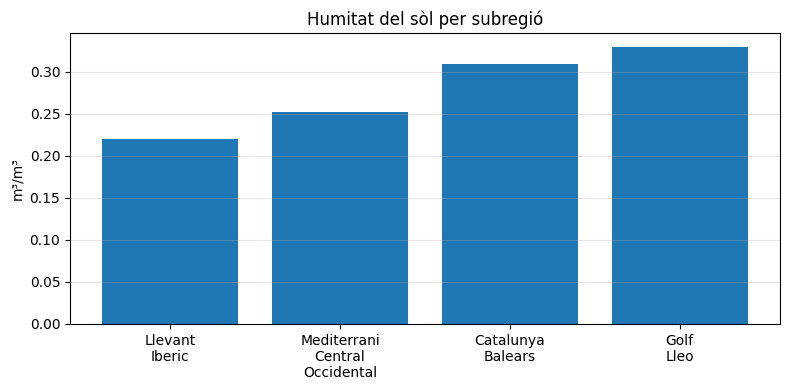

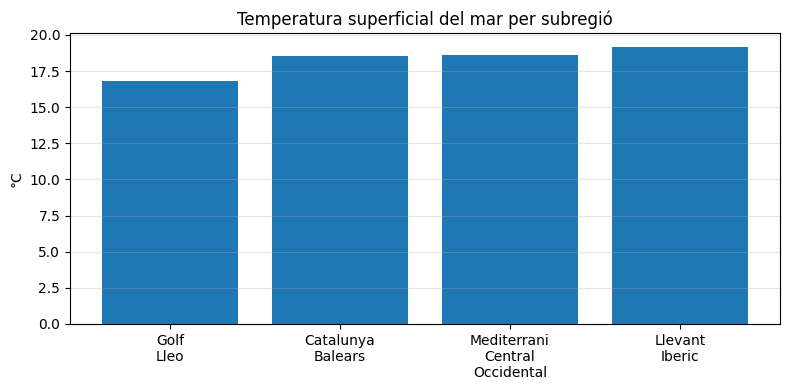

In [9]:
def etiqueta_curta(text):
    return text.replace("_", "\n")

for col, title, ylabel in [
    ("temperatura_mitjana", "Temperatura mitjana per subregió", "°C"),
    ("precipitacio_mensual_mm", "Precipitació mensual mitjana per subregió", "mm/mes"),
    ("humitat_sol_capa1", "Humitat del sòl per subregió", "m³/m³"),
    ("temperatura_superficie_mar", "Temperatura superficial del mar per subregió", "°C"),
]:
    temp = resum_subregio.sort_values(col)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(temp["subregio"], temp[col])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(range(len(temp["subregio"])))
    ax.set_xticklabels([etiqueta_curta(x) for x in temp["subregio"]], rotation=0)

    plt.tight_layout()
    plt.savefig(FIG / f"02_subregio_{col}.png", dpi=300)
    plt.show()